---
title: "Deelvraag 3"
subtitle: "Evaluatie van een Random Forest-model"
title-block-style: plain
author: "Jalisa Shaline van der Zeeuw"
date: "January 2026"
format:
  pdf:
    geometry: margin=2.5cm
    include-code: false
number-sections: false
execute:
  echo: false
  warning: false
  message: false
---

In [1]:
import sys

EXPECTED_ENV = "ml_oncoresponse"

if EXPECTED_ENV not in sys.prefix:
    print(
        "⚠️ WAARSCHUWING: mogelijk verkeerde conda environment\n"
        f"Verwacht: {EXPECTED_ENV}\n"
        f"Huidig: {sys.prefix}\n"
        "Resultaten kunnen afwijken."
    )

# Analyse van modelprestatie...
In dit notebook wordt de voorspellingsprestatie van een Random Forest-regressiemodel geëvalueerd voor het voorspellen van drug-respons (AUC-waarden) op basis van pathway-gebaseerde mutatie- en methylatiefeatures bij longkankercellijnen.

Het doel van deze analyse is het beantwoorden van **deelvraag 3:**
*Hoe goed presteert het getrainde Random Forest-model bij het voorspellen van de drugrespons van longkankercellijnen, gemeten aan de hand van R^2 en RMSE?*

[Het doel is uiteindelijk niet om te kijken welke methode wint, maar om te kijken of de verschillende evaluaties een consistent beeld geven van de performance.]

In eerdere notebooks lag de focus op datapreparatie en interpretatie van het model (feature importance). In dit notebook ligt de nadruk op het evalueren van de modelprestatie. Daarbij wordt onderzocht hoe nauwkeurig het model AUC-waarden kan voorspellen en hoe consistent deze prestaties zijn over verschillende trainings- en testsets.

Voor deze evaluatie wordt, net als in `dv2_model_interpretatie.ipynb`, gemodelleerd op het geneesmiddel `PF005212384`. De keuze is gebaseerd op datacompleetheid, behoud van samplegrootte [en de beschikbaarheid van biologische achtergrondkennis, waardoor de resultaten beter geïnterpreteerd kunnen worden].

Omdat de dataset relatief klein is (82 cellijnen), wordt geen vaste train-test split gebruikt. Een enkele split kan leiden tot een kleine en toevallige testset, waardoor de evaluatie sterk afhankelijk wordt van één specifieke verdeling van de data. In plaats daarvan wordt gebruikgemaakt van cross-validatie, waarbij het model herhaaldelijk wordt getraind op een deel van de data en getest op cellijnen die in die training niet zijn gebruikt. Op deze manier wordt elke cellijn één keer gebruikt als ongeziene testdata en kan de voorspellingsprestatie betrouwbaarder worden ingeschat.

Out-of-bag (OOB) voorspellingen worden daarnaast gebruikt als interne schatting van modelprestatie en als referentiepunt bij de hyperparameterverkenning. De uiteindelijke beoordeling van de modelprestatie is gebaseerd op de resultaten van de cross-validatie.

Omdat AUC een continue maat is voor geneesmiddelrespons, wordt het model geëvalueerd met foutgebaseerde maten (RMSE en MAE) en verklaarde variantie (R^2). RMSE wordt gebruikt als primaire maat, omdat deze direct interpreteerbaar is in AUC-eenheden en grotere voorspellingsfouten zwaarder laat meewegen. MAE wordt toegevoegd als aanvullende maat, omdat deze de gemiddelde absolute fout weergeeft en minder gevoelig is voor uitschieters. R^2 wordt gerapporteerd om aan te geven in hoeverre het model variatie in drug-respons kan verklaren ten opzichte van een eenvoudig basismodel.

Naast numerieke evaluatiematen worden visualisaties gebruikt om omdelprestaties inzichtelijk te maken. Een scatterplot van gemeten versus voorspelde AUC-waarden wordt gebruikt om de overeenkomst tussen voorspellingen en waarnemingen te beoordelen. Boxplot van cross-validatieresultaten worden gebruikt om de spreiding en stabiliteit van de prestaties over verschillende datasplits te tonen.

[kan ook nog Spearman toevoegen (rankink ipv absolute fout) maar dan in deelvraag wel explictier benomen, staat er nu niet in]

## Data-invoer en selectie


Voor deze analyse worden twee datasets gebruikt:  
- X: een pathway-level featurematrix, voorbereid in notebook *dv1_dataprep.ipynb* (`pathway_features.pkl`).  
- y: drug-responsdata, voorbereid in notebook *dataprep_response.ipynb* (`response_matrix.pkl`)

Om datalek te voorkomen worden features `(X)` en respons `(y)` gescheiden ingeladen. Met datalek wordt bedoeld dat het model onbedoeld toegang krijgt tot informatie die het in de praktijk niet zou hebben. Bijvoorbeeld doordat features zijn gemaakt of geselecteerd met kennis van de drug-respons, of dat bij het trainen gebruik is gemaakt van informatie uit alle data. Hierdoor kan een model beter lijken te preseteren dan het in werkelijkheid zou doen op nieuwe data, ongeziene data.

Ter controle wordt eerst de dimensie van beide datasets weergegeven. Vervolgens wordt uit de responsmatrix één geneesmiddel geslecteerd, zoals in de inleiding gemotiveerd is, in dit geval `PF-05212384`. De bijbehorende AUC-waarden vormen in dit notebook de doelvariabele.

Tot slot worden de twee datasets samengevoegd op basis van de cellijnen. Hierbij worden alleen cellijnen meegenomen waarvoor zowel pathway-kenmerken als geneesmiddelrespons beschikbaar zijn. De resulterende datasets vormen de definitieve invoer voor dit notebook en worden gebruikt voor modeltraining en verdere analyse (in de code aangeduid als `X_aligned` en `y_aligned`).

**Uitkomst van deze stap**

Na afstemming zijn gegevens beschikbaar voor 82 cellijnen, elk beschreven door 100 pathway-features. Deze 82 cellijnen vormen de de definitieve dataset voor verdere analyse.


## Verdeling van de responsvariabele

Voordat het model wordt opgezet, is de verdeling van de AUC-waarden verkend. Dit dient als een kwaliteitscontrole om te beoordelen of de respons sterke scheefheid of extreme uitschieters vertoont die van invloed kunnen zijn op de keuze van modelinstellingen en evaluatiematen.

In Figuur 1 is een boxplot weergegeven van de AUC-waarden van het gekozen geneesmiddel, `PF-05212384`.

In [2]:
import pandas as pd

# inladen van de datasets
X = pd.read_pickle("../data/processed/pathway_features.pkl")      # featurematrix
y = pd.read_pickle("../data/processed/response_matrix.pkl")      # drug-responsmatrix

# controle shape
print("Featurematrix (X):", X.shape)
print("Responsmatrix (y):", y.shape)


# selecteren van één geneesmiddel
drug_name = "PF-05212384"
y_drug = y[drug_name]

print("Aantal cellijnen met responsdata vóór afstemming:", y_drug.shape[0])

# afstemming van X en y
common_ids = X.index.intersection(y_drug.index)

X_aligned = X.loc[common_ids].copy()
y_aligned = y_drug.loc[common_ids].copy()

print("Aantal cellijnen na afstemming:", X_aligned.shape[0])
print("Aantal features:", X_aligned.shape[1])

# extra controle

assert all(X_aligned.index == y_aligned.index), "Indexen van X en y komen niet overeen!"


Featurematrix (X): (82, 100)
Responsmatrix (y): (93, 1450)
Aantal cellijnen met responsdata vóór afstemming: 93
Aantal cellijnen na afstemming: 82
Aantal features: 100


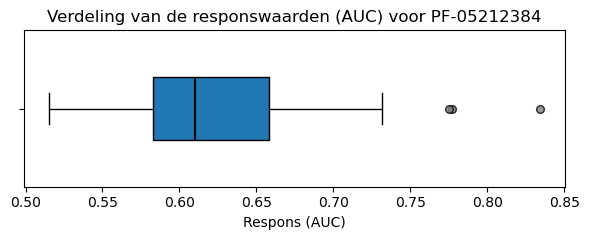

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 2.5))

plt.boxplot(
    y_aligned,
    vert=False,
    patch_artist=True,
    widths=0.4,
    boxprops=dict(color="black", linewidth=1),
    whiskerprops=dict(color="black", linewidth=1),
    capprops=dict(color="black", linewidth=1),
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(
        marker='o',
        markersize=5.5,
        markerfacecolor='grey',
        markeredgecolor='black',
        alpha=0.8
    )
)

# As-instellingen
plt.yticks([1], [])
plt.xlabel("Respons (AUC)")
plt.title("Verdeling van de responswaarden (AUC) voor PF-05212384")

plt.tight_layout()
plt.show()


***Figuur 1**. Boxplot van de AUC-waarden (n=82) van geneesmiddel PF-05212384.
Minumum = 0.52, maximum = 0.83, gemiddelde = 0.62, mediaan = 0.61, SD = 0.06*

De AUC-waarden liggen in een relatief smal bereik, waarbij het gemiddelde en mediaan dicht bij elkaar liggen. De boxplot toont enkele uitschieters, maar geen sterke scheefheid of extreme waarden. Dit wijst erop dat de responsverdeling geschikt is voor standaard regressiebenaderingen.

## Modelopzet en hyperparameters


In dit notebook wordt Random Forest Regressie gebruikt om de relatie tussen pathway-kenmerken en geneesmiddelrespons te modelleren. De keuze voor dit model en de theoretische achtergrond worden uitgebreid besproken in bewijsstuk `model_rf` (te vinden bij criterium 1). Hier worden uitsluitend de concrete modelinstellingen beschreven die relevant zijn voor de verdere evaluatie. 

Het doel is hier niet om het model maximaal te optimaliseren, maar om de gekozen instellingen te motiveren en te onderbouwen, zodat de daaropvolgende evaluatie betekenisvol is. [laten zien dat ik begrijp wat de parameters doen. Laten zien dat ik dus na denk over mijn keuze in deze parameters en niet blind wat gebruik. --> criteium?].

#### Relevante hyperparameters

Het Random Forest-model kent verschillende instellingen (hyperparameters) die bepalen hoe het model wordt opgebouwd. In dit notebook worden alleen de parameters besproken die een sterke invloed hebben op de complexiteit en stabiliteit van het model. De beschrijvingen hieronder zijn gebaseerd op de documentatie van [scikit-learn RandomForestRegressor](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html?_x_tr_sl=en&_x_tr_tl=nl&_x_tr_hl=nl&_x_tr_pto=sc)

**Aantal bomen (`n_estimators`)**

Deze parameter bepaalt uit hoeveel beslissingsbomen het Random Forest bestaat. Meer bomen leiden tot stabielere en minder toevallige voorspellingen, maar verhogen ook de rekentijd. 

**Maximale boomdiepte (`max_depht`)**  
Deze parameter bepaalt hoe diep elke beslissingsboom mag worden. Diepere bomen kunnen complexere patronen leren, maar hebben ook een grotere kans om zich te veel aan te passen aan trainingsdata (overfitting). Door maximale diepte te beperken kan het model worden gedwongen om meer algemene patronen te leren.

**Aantal features per splitsing (`max_features`)**  
Bij elke splitsing in een boom wordt slechts een deel van alle beschikbare features overwogen. Een kleinere waarde zorgt ervoor dat verschillende bomen verschillende kenmerken gebruiken, waardoor de bomen minder op elkaar lijken. Dit vergroot de stabiliteit van het forest en verkleint de kans op overfitting.

**Minimale grootte van eindknopen(`min_samples_leaf)`**  
Deze parameter bepaalt hoeveel cellijnen minimaal in een eindknoop aanwezig moeten zijn. Hogere waarden waarden voorkomen dat bomen zich volledig aanpassen aan zeer kleine groepen of individuele uitschieters. Dit vermindert de kans dat toevallige patronen in een kleine dataset worden geleerd, maar kan ten koste gaan van het modelleren van zeldzame effecten.

**Splitsingscriterium(`squared_error`)**  
Als splitsingscriterium wordt de standaardinstelling gebruikt. Hierbij worden splitsingen gekozen die de spreiding van AUC-waarden binnen de resulterende groep zo klein mogelijk maken, waarbij grote fouten extra zwaar meetellen. Dit criterium is geschikt voor continue responsmaten zoals AUC en sluit aan bij de gebruikte evaluatiemetric RMSE. 

## Verkenning en keuze van hyperparameters


In deze sectie wordt (in beperkte mate) verkend hoe enkele kerninstellingen van het Random Forest-model het gedrag en de stabiliteit van het model beïnvloeden. Het doel is niet om het model maximaal te optimaliseren, maar om te controleren of de gekozen instellingen leiden tot stabiele en redelijke prestaties. Hiervoor wordt gebruiktgemaakt van de out-of-bag (OOB) fout als interne schatting van de modelprestatie. 

Op basis van deze verkenning worden vervolgens de instellingen vastgelegd die in de verdere modelevaluatie worden gebruikt.


**Startmodel en eerste OOB-evaluatie**  

Om te beginnen wordt een Random Forest-model met standaardinstellingen getraind. Dit model dient als uitgangspunt voor verdere verkenning.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_start = RandomForestRegressor(
    n_estimators=300,
    criterion="squared_error",
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=1,
    oob_score=True,
    random_state=17,
    n_jobs=-1
)

rf_start.fit(X_aligned, y_aligned)

# OOB voorspellingen
oob_pred = rf_start.oob_prediction_

# OOB RMSE
oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))

# overzicht van belangrijkste instellingen van het startmodel
print("Startmodel instellingen:")
print("Aantal bomen (n_estimators):", rf_start.n_estimators)
print("Max features per splitsing (max_features):", rf_start.max_features)
print("Maximale boomdiepte (max_depth):", rf_start.max_depth)
print("Minimale bladgrootte (min_samples_leaf):", rf_start.min_samples_leaf)
print("Splitsingscriterium (criterion):", rf_start.criterion)
print("Out-of-bag evaluatie (oob_score):", rf_start.oob_score)
print()
print("OOB RMSE (startmodel):", round(oob_rmse, 4))


Startmodel instellingen:
Aantal bomen (n_estimators): 300
Max features per splitsing (max_features): sqrt
Maximale boomdiepte (max_depth): None
Minimale bladgrootte (min_samples_leaf): 1
Splitsingscriterium (criterion): squared_error
Out-of-bag evaluatie (oob_score): True

OOB RMSE (startmodel): 0.0616


Het startmodel resulteert in een OOB RMSE van 0.0616. Deze waarde wordt gebruikt als referentiepunt bij de verkenning van hyperparameters.

In de volgende stap wordt gekeken of het aantal bomen in het model voldoende is. Het Random Forest-model wordt getraind met verschillende aantallen bomen, terwijl alle overige instellingen gelijk blijven. 

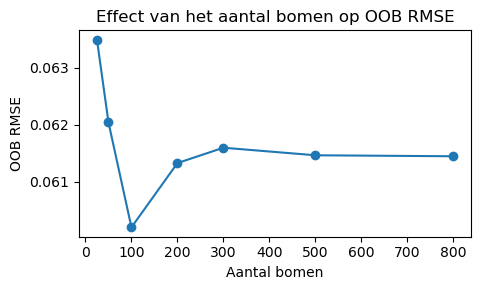

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

n_estimators_list = [25, 50, 100, 200, 300, 500, 800]
oob_rmse_list = []

for n in n_estimators_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        criterion="squared_error",
        max_features="sqrt",
        max_depth=None,
        min_samples_leaf=1,
        oob_score=True,
        random_state=17,
        n_jobs=-1
    )
    
    rf.fit(X_aligned, y_aligned)
    oob_pred = rf.oob_prediction_
    oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))
    oob_rmse_list.append(oob_rmse)

# Plot
plt.figure(figsize=(5,3))
plt.plot(n_estimators_list, oob_rmse_list, marker='o')
plt.xlabel("Aantal bomen")
plt.ylabel("OOB RMSE")
plt.title("Effect van het aantal bomen op OOB RMSE")
plt.tight_layout()
plt.show()


***Figuur 2**. Out-of-bag RMSE als functie van het aantal bomen in het Random Forest-model. Voor elk aantal bomen is het model opnieuw getraind met identieke instellingen, waarbij de OOB-samples zijn gebruikt om de voorspellings te schatten.*

De OOB RMSE daalt nog licht bij het verhogen van het aantal bomen tot ongeveer 100. Bij verdere verhoging blijft de fout stabiel en schommelt deze rond een vergelijkbare waarde. Dit wijst erop dat de prestaties vanaf circa 100 bomen stabiel zijn. Op basis hiervan is gekozen om de `n_estimators` in te stellen op 300 bomen, wat ruim binnen het stabiele gebied ligt.

Nu is vastgesteld dat het model stabiele prestaties toont, wil ik kijken naar een tweede hyperparameter die direct invloed heeft op de complexiteit van het model. Omdat de dataset relatief klein is (n=82) en biologische data gevoelig kan zijn voor ruis, is het relevant om te onderzoeken in hoeverre het model zich aanpast aan zeer kleine groepen obervaties. Dit wordt verkend met de parameter `min_samples_leaf`.

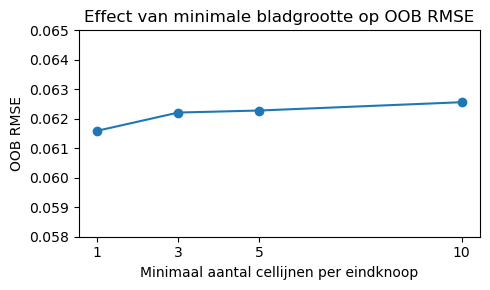

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

leaf_sizes = [1, 3, 5, 10]
oob_rmse_leaf = []

for leaf in leaf_sizes:
    rf = RandomForestRegressor(
        n_estimators=300,
        criterion="squared_error",
        max_features="sqrt",
        max_depth=None,
        min_samples_leaf=leaf,
        oob_score=True,
        random_state=17,
        n_jobs=-1
    )
    
    rf.fit(X_aligned, y_aligned)
    oob_pred = rf.oob_prediction_
    oob_rmse = np.sqrt(mean_squared_error(y_aligned, oob_pred))
    oob_rmse_leaf.append(oob_rmse)
    

# Plot
plt.figure(figsize=(5,3))
plt.plot(leaf_sizes, oob_rmse_leaf, marker='o')
plt.xlabel("Minimaal aantal cellijnen per eindknoop")
plt.ylabel("OOB RMSE")
plt.title("Effect van minimale bladgrootte op OOB RMSE")
plt.xticks(leaf_sizes)
plt.ylim(0.058, 0.065)
plt.tight_layout()
plt.show()


***Figuur 3**. Out-of-bag RMSE bij verschillende waarden voor de minimale bladgrootte (`min_samples_leaf`). De OOB RMSE varieert slechts beperkt tussen 0.0616 en 0.0623, wat wijst op een minimale gevoeligheid van het model voor deze parameter.*

De OOB RMSE verschilt slechts minimaal tussen de geteste waarden voor `min_samples_leaf`. Hogere waarden leiden niet tot een verbetering van de prestatie, maar eerder tot een lichte verslechtering. Dit wijst erop dat het model bij de standaardinstelling geen tekenen van overfitting vertoont.

Hogere waarden voor `min_samples_leaf` beperken het model, omdat splitsingen op kleine groepen cellijnen dan niet meer zijn toegestaan. Hierdoor kan mogelijk informatie verloren gaan en kunnen minder patronen worden geleerd. Omdat meer cellijnen per eindknoop in deze analyse geen verbetering oplevert, is gekozen voor de minst beperkende instelling (`min_samples_leaf` = 1).


#### Conclusie hyperparameterverkenning

In deze sectie is onderzocht of het startmodel voldoende stabiele en redelijke prestaties vertoont, en of aanpassing van kerninstellingen noodzakelijk is. Uit de analyse blijkt dat de OOB RMSE stabiliseert bij hogere aantallen bomen en dat het model slechts beperkt gevoelig is voor de minimale bladgrootte. Er zijn geen aanwijzingen gevonden dat het model instabiel is of zich te sterk aanpast aan kleine groepen observaties. Op basis van deze bevindingen wordt het startmodel gehandhaafd als definitief model voor de verdere evaluatie.

### Definitied model voor evaluatie

Op basis van de voorgaande hyperparameterverkenning is één definitief RF-model vastgelegd (genaamd `rf_final`). Dit model is getrind op de volledige dataset en is in principe gereed om voorspellingen te genereren voor nieuwe observaties. Zie onderstaande tabel voor een overzicht van de belangrijkste instellingen.

***Tabel 1.** Overzicht van de belangrijkste instellingen van het definitieve Random Forest-model.*

In [7]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# definitief RF-model
rf_final = RandomForestRegressor(
    n_estimators=300,
    criterion="squared_error",
    max_features="sqrt",
    max_depth=None,
    min_samples_leaf=1,
    oob_score=True,
    random_state=17,
    n_jobs=-1
)

# train model
rf_final.fit(X_aligned, y_aligned)

# Tabel met relevante instellingen
params = {
    "Aantal bomen (n_estimators)": rf_final.n_estimators,
    "Splitsingscriterium": rf_final.criterion,
    "Max features per splitsing": rf_final.max_features,
    "Maximale boomdiepte": rf_final.max_depth,
    "Minimale bladgrootte": rf_final.min_samples_leaf,
    "Out-of-bag evaluatie": rf_final.oob_score,
    "Random seed": rf_final.random_state
}

params_df = pd.DataFrame.from_dict(params, orient="index", columns=["Waarde"])
params_df

,Waarde
Aantal bomen (n_estimators),300
Splitsingscriterium,squared_error
Max features per splitsing,sqrt
Maximale boomdiepte,None
Minimale bladgrootte,1
Out-of-bag evaluatie,True
Random seed,17


## Modelevaluatie

Het doel van dit notebook was om een Randon Forest-model te trainen en vervolgen te kijken hoe goed dit model presteert bij het voorspellen van drugrespons van longkankercellijnen (, gemeten aan de hand van R^2 en RMSE). In machine learning wordt deze vraag normaal gesproken beantwoord door een model te trainen op een deel van de data en de prestaties te meten op een apart gehouden testset (train/test split). Hoe goed zal het model presteren op *nieuwe, ongeziene data?*

In dit onderzoek is er bewust voor gekozen om geen vaste train-test split uit te voeren. De dataset bevat slechts 82 observaties. Bij een gebruikelijke 80/20-verdeling zouden slechts 16 cellijnen beschikbaar zijn voor testing. Bij zulke kleine testsets worden prestatiematen sterk beinvloed door toeval. Specifieke cellijnen kunnen toevallig in de testset terechtkomen en een groot effect hebben op de uitkomst. Dit leidt tot instabiele evaluaties en maakt het dus lastig om eerlijke conclusies te trekken over de werkelijke generalisatieprestatie van het model.

Daarnaast is het uiteindelijke Random Forest-model in dit onderzoek bewust getraind op de volledige dataset, om maximaal gebruik te maken van de beschikbare biologische informatie voor interpretatie en analyse. Hierdoor is er geen onafhankelijke testset meer beschikbaar om dit specifieke eindmodel eerlijk te evalueren. 

De deelvraag kan niet direct beantwoord worden beantwoord voor dit definitieve eindmodel (`rf_final`). Wel kan een schatting worden gemaakt van de verwachte prestatie van een Random Forest-model op nieuwe, ongeziene data. Deze schatting is gebaseerd op herhaald trainen en tunen van modellen volgens exact dezelfde procedure als is gebruikt bij het opstellen van het eindmodel. Om deze schatting op een verantwoorde en minder toevalsgerichte manier te verkrijgen bij een beperkte dataset, is er gekozen om gebruik te maken van nested cross-validatie. 

#### Evaluatiestrategie: nested cross-validatia (CV) met OOB-tuning

Deze methode combineert twee ideeen: herhaald testen op ongeziene data en het opnieuw afstemmen van het model binnen elke trainingsset.

**Stap 1. Herhaald trainen en testen (simple cross-validatie)**

In plaats van de data één keer te splitsen in een trainingsset en een testset, wordt de dataset opgedeeld in meerdere gelijke delen (folds). Telkens wordt één deel apart gehouden als testset terwijl de overige delen worden gebruikt om het model te trainen. Dit proces wordt herhaald totdat elk deel één keer een testset is geweest. Op deze manier wordt het model meerdere keren getest op andere, ongeziene data. Dit vermindert de invloed van toeval en levert een stabielere schatting op dan één enkele train-test split.

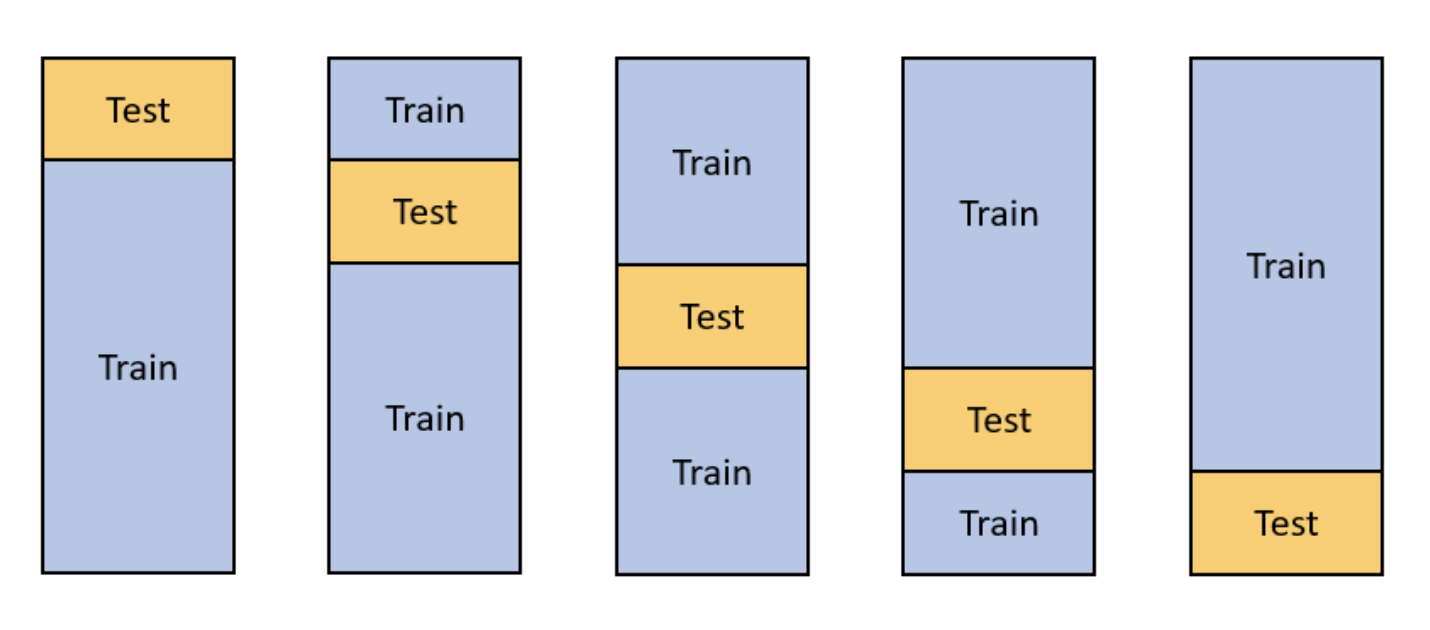

**Stap 2. Waarom dit nog niet voldoende is**

In de praktijk wordt een model niet met vaste instellingen getraind. De instellingen, (hyperparameters) die eerder zijn beschreven in dit notebook, worden afgestemd op de trainingsdata. Dit afstemmen is zelf ook een leerproces. Als deze stap niet wordt meegenomen binnen de herhaalde opsplitsingen, kan de prestatie te optimistisch worden ingeschat. Daarom moet niet alleen het trainen, maar ook het afstemmen van het model steeds opnieuw gebeuren binnen de trainingsdata.

**Stap 3. Nested CV: trainen, afstemmen en testen gescheden**

Nested cross-validatie breidt gewone cross-validatie uit door binnen elke trainingsset opnieuw een interne verdeling te maken. Elke herhaling bestaat nu uit twee niveaus:  
- Outer loop: één deel van de data wordt apart gehouden als ongeziene testset. Deze stap is bedoeld om te prestatie te meten.
- Inner loop: binnen de overgebleven trainingsdata worden modellen getraind en afgestemd. In dit onderzoek gebeurt deze afstemming met behulp van OOB validatie (net zoals is gedaan bij het trainen en afstemmen van het definitieve model dat is gemaakt).

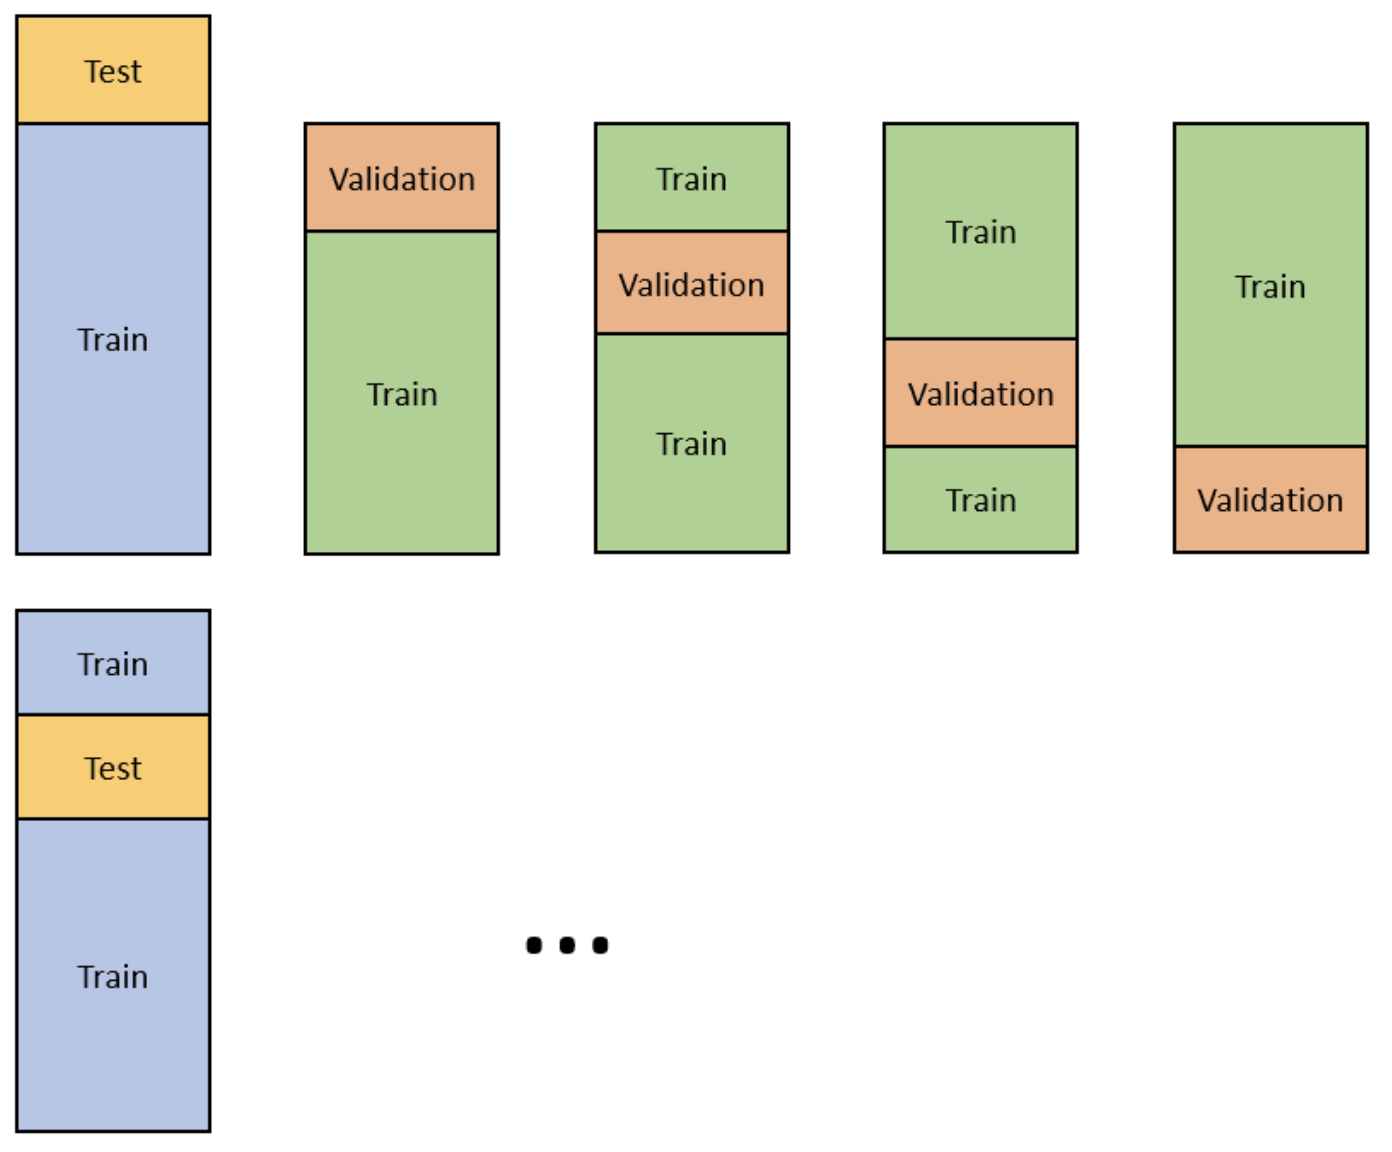

Samengevat wordt bij elke herhaling:  
1. een deel van de data volledig apart gehouden,  
2. op de overige data meerdere RF-modellen getraind,  
3. de instellingen gekozen op basis van OOB-fout,  
4. één model met deze instellingen getraind,  
5. dit model getest op de apart gehouden data.  

**Interpretatie:** Deze procedure levert meerdere prestatiematen op (één per herhaling). Het gemiddelde en de spreiding van deze waarden vormen een schatting van hoe goed een RF-model, getraind en afgestemd volgens deze procedure, naar verwachting zal preseteren op nieuwe data (longkankercellijnen).

Nested cross-validatie evalueert daarmee niet één specifiek eindmodel, maar het volledige leerproces: instellingen kiezen, model trainen en toepassen op nieuwe data. 


## Evaluatiematen

De prestaties van de RF-leerprocdure worden beoordeeld met behulp van regressiematen, aangezien de drugrespons een continue variabele is. In dit onderzoek worden twee evaluatiematen gebruikt:

**RMSE (Root Mean Squared Error)**  
RMSE is de wortel van de gemiddelde gekwadrateerde fout en heeft daardoor dezelfde schaal als de responsvariabele, waardoor de fout direct interpreteerbaar is.

**R^2 (coefficient van determinatie)**  
R^2 geeft aan welk deel van de variantie in de drugrespons door het model wordt verklaard. Deze maat biedt een genormaliseerde indicatie van de voorspelkracht van het odel en wordt gebruikt als aanvullende evaluatiemaat.

## Opzet nested CV

In de volgende analyse is gekozen voor 10-fold nested CV. Deze keuze is bewust gemaakt vanwege de beperkte dataomvang. Bij 10 folds bevat elke testset ongeveer 8 observaties, terwijl bij 5-fold cross-validatie elke testset ongeeer 16 observaties zou bevatten. Door meer folds te gebruiken, wordt elk model getraind op een groter deel van de data (ongeveer 90% in plaats van 80%), wat bij kleine datasets wenselijk is om zoveel mogelijk informatie te benutten tijdens de training. Daarnaast levert 10-fold cv meer onafhankelijke testsituaties op, waardoor een stabielere schatting ontstaat van de verwachte prestatie. Het nadeel van hogere aantal folds is een grotere rekentijd, maar dat is in dit geval geen beperking.

In [8]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# outer CV
outer_cv = KFold(n_splits=10, shuffle=True, random_state=17)

# hyperparameters om te verkennen (inner loop)
n_estimators_list = [100, 200, 300, 500]
min_samples_leaf_list = [1, 3, 5, 10]

In [9]:
rmse_scores = []
r2_scores = []
mae_scores = []

chosen_params = []

In [10]:
fold = 1

for train_idx, test_idx in outer_cv.split(X_aligned):

#    print(f"\nOuter fold {fold}")

    X_train = X_aligned.iloc[train_idx]
    X_test  = X_aligned.iloc[test_idx]
    y_train = y_aligned.iloc[train_idx]
    y_test  = y_aligned.iloc[test_idx]

    
# INNER LOOP  (OOB tuning)
    

    best_oob_rmse = np.inf
    best_params = None

    for n in n_estimators_list:
        for leaf in min_samples_leaf_list:

            rf_inner = RandomForestRegressor(
                n_estimators=n,
                criterion="squared_error",
                max_features="sqrt",
                max_depth=None,
                min_samples_leaf=leaf,
                oob_score=True,
                random_state=17,
                n_jobs=-1
            )

            rf_inner.fit(X_train, y_train)

            oob_pred = rf_inner.oob_prediction_
            oob_rmse = np.sqrt(mean_squared_error(y_train, oob_pred))

            if oob_rmse < best_oob_rmse:
                best_oob_rmse = oob_rmse
                best_params = (n, leaf)

#    print("  Beste OOB-parameters:", best_params)
    chosen_params.append(best_params)


# train eindmodel


    rf_final_fold = RandomForestRegressor(
        n_estimators=best_params[0],
        criterion="squared_error",
        max_features="sqrt",
        max_depth=None,
        min_samples_leaf=best_params[1],
        random_state=17,
        n_jobs=-1
    )

    rf_final_fold.fit(X_train, y_train)


# test op ongeziene fold


    y_pred = rf_final_fold.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)
    mae_scores.append(mae)

#    print(f"  RMSE: {rmse:.4f} | R2: {r2:.4f} | MAE: {mae:.4f}")

    fold += 1


**Resultaten hyperparameterselectie binnen nested cross-valisatie**

Binnen elke outer fold zijn de hyperparameters opnieuw afgestemd met behulp van OOB validatie. Het gekozen aantal bomen varieerde tussen 100 en 500, waarbij waarden vanaf 100 bomen frequent werden geselecteerd (consistent met de eerdere observatie).

Voor de minimale bladgrootte werden zowel lage waarden (1-3) als hogere waarden (10) geselecteerd. Dit geeft aan dat er geen stabiele optimale instelling is voor de minimale bladgrootte en dat de modelcomplexiteit afhankelijk is van de specifieke trainingsdata.

**Resultaten nested cross-valisatie**

In Tabel 2 zijn de prestaties weergegeven voor elke outer fold afzonderlijk. Elke rij komt overeen met één onafhankelijke evaluatie binnen de nested cross-validatie, waarbij het model is getraind en afgestemd op de trainingsfolds en getest op een ongeziene testfold.


***Tabel 2.** Prestaties per outer fold (RMSE, R^2 en MAE) verkregen met 10-fold nested cross-validatie.*

In [11]:
results_df = pd.DataFrame({
    "RMSE": rmse_scores,
    "R2": r2_scores,
    "MAE": mae_scores
})

results_df

,RMSE,R2,MAE
0,0.058128,-0.072840,0.049627
1,0.065800,-0.067287,0.056590
2,0.076998,-0.557136,0.068220
3,0.034370,0.047467,0.029823
4,0.062919,0.161915,0.048007
5,0.081883,-0.018963,0.049558
6,0.042413,-0.283226,0.033905
7,0.045601,-0.623344,0.040200
8,0.056473,-0.131205,0.046351
9,0.080129,-0.100295,0.067570


Tabel 3 toont een samenvatting van de nested cross-validatie resultaten. Hierin zijn het gemiddelde, de standaarddeviatie en het bereik van de prestaties over de outer folds weergegeven. Deze vormen de belangrijkste schatting van de verwachte generalisatieprestatie.

***Tabel 3.** Samenvatting van de nested cross-validatie resultaten*

In [12]:
from IPython.display import display

display(results_df.describe())


,RMSE,R2,MAE
count,10.000000,10.000000,10.000000
mean,0.060472,-0.164491,0.048985
std,0.016338,0.252661,0.012709
min,0.034370,-0.623344,0.029823
25%,0.048319,-0.245221,0.041738
50%,0.060523,-0.086567,0.048782
75%,0.074199,-0.031044,0.054849
max,0.081883,0.161915,0.068220


De verdeling van de RMSE-waarden over de outer folds van de nested cross-validation is te zien in Figuur 4. Deze figuur geeft inzicht in de gemiddelde grootte van de voorspellingsfout en in de mate waarin de prestaties variëren tussen verschillende datasplitsingen.

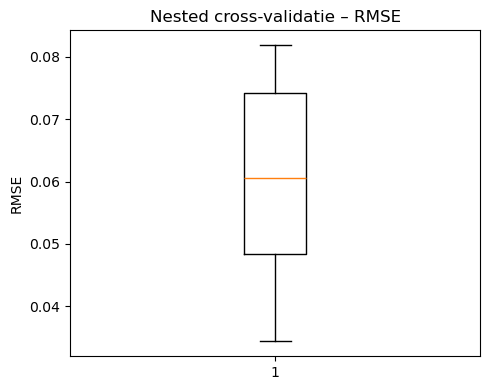

In [13]:
plt.figure(figsize=(5,4))
plt.boxplot(rmse_scores)
plt.ylabel("RMSE")
plt.title("Nested cross-validatie – RMSE")
plt.tight_layout()
plt.show()


***figuur 4.** Boxplot van de RMSE-waarden over de 10 outer folds van de nested cross-validatie. De RMSE geeft de gemiddelde voorspellingsfout in AUC-eenheden weer.

De RMSE-waarden variëren tussen ongeveer 0.034 en 0.082, met een gemiddelde rond de 0.06. De spreiding tussen de folds is groot, wat wijst op variatie in prestaties afhankelijk van de datasplitsing.

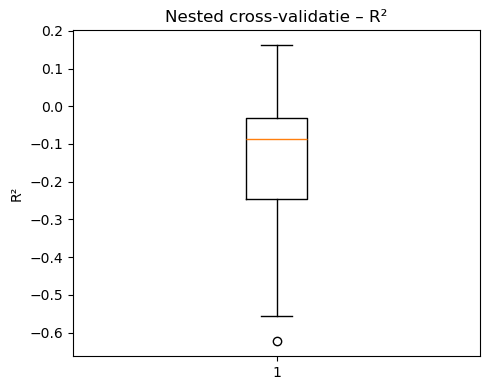

In [14]:
plt.figure(figsize=(5,4))
plt.boxplot(r2_scores)
plt.ylabel("R²")
plt.title("Nested cross-validatie – R²")
plt.tight_layout()
plt.show()

***Figuur 5.** Boxplot van de R^2-waarden over de 10 outer folds van de nested cross-validatie. Negatieve waarden duiden erop dat het model slechter presteert dan het meest simpele model dat steeds de gemiddelde respons voorspelt.*

De R^2-waarden vertonen een brede spreiding en zijn in de meeste folds negatief. Slechts in enkele folds worden licht positieve waarden waargenomen.

# Interpretatie en en beantwoording deelvraag

De derde deelvraag van dit onderzoek was: "Hoe goed presteert het getrainde Random Forest-model bij het voorspellen van de drugrespons van longkankercellijnen, gemeten aan de hand van R² en RMSE?".

Voor het definitieve Random Forest-model dat op de volledige dataset is getraind, kan deze vraag niet rechtstreeks worden beantwoord/ Dit model is namelijk niet direct geëvalueerd op een volledig onafhankelijke testset. Zo een evaluatie zou bij deze beperkte datasetomvang sterk afhankelijk zijn van toeval en geen betrouwbare schatting geven.

In plaats daarvan is met behulp van 10-fold nested cross-validatie een schatting gemaakt van de verwachte prestatie van de leerprocedure op nieuw, ongeziene data.

### Samenvatting van de prestaties

De nested cross-validatie resulteerde in een gemiddelde RMSME van ongeveer 0.06 en een gemiddelde MAE van ongeveer 0.05. Dit betekent dat de voorspelde drugrespons gemiddeld circa 0.05-0.06 AUC-eenheden afwijkt van de gemeten waarden.In absolute zin blijft de voorspellingsfout daarmee relatief beperkt.

De R^2-waarden varieerden sterk tussen de outer folds en waren in de meeste gevallen negatief, met een gemiddelde rond -0.16. Dit betekent dat het model gemiddeld niet beter presteerd dan een eenvoudig nulmodel (simpelste model) dat voor alle cellijnen de gemiddelde drugrespons voorspelt. Slechts in enkele folds werd een licht positieve R^2 waargenomen, wat er op wijst dat in sommige datasplitsingen een zwak voorspellend patroon aanwezig was, maar dit patroon niet stabiliseert.

Dit resultaat is in lijn met wat verwacht kan worden bij een kleine biologische dataset. Bij kleine datasets hebben toevallige meetvariaties en uitschieters relatief veel invloed. Hierdoor kan het odel patronen leren die niet stabiel zijn en sterk afhankelijk zijn van de spepcifieke samenstelling van de trainingsset. 

Daarnaast is drugrespons complex en wordt het door veel biologische factoren beinvloed. In dit onderzoek is slechts een beperkt deel van deze facoren meegenomen, wat de beperkte voorspelbaarheid van de respons verklaart.